In [1]:
# ============================================================
# Core imports + config
# ============================================================
import os, sys, gc
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
from scipy.ndimage import gaussian_filter
from scipy.integrate import trapezoid
import seaborn as sns
import pickle
from tqdm.auto import tqdm

dt = 0.005
t_pre, t_post = 0.3, 0.3

USE_MACRO_EPOCH = True   # True=contiguous Condition blocks, False=peri-event windows
CEBRA_DISTANCE = "cosine"  # "cosine" or "euclidean"
MIN_EPOCH_DUR = 2.0      # minimum macro-epoch duration (seconds)

NAS = r"\\129.199.81.18\data5\eTheremin"

mpl.rcdefaults()
plt.rcParams.update({
    'font.size': 7, 'axes.linewidth': 0.5,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.major.width': 0.5, 'ytick.major.width': 0.5,
    'xtick.major.size': 2, 'ytick.major.size': 2,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})
print("Imports ready.")

Imports ready.


In [2]:
# ============================================================
# Load spike-sorted Skieur data
# ============================================================

def load_pickled_ss(file_prefix, session_type, dt):
    data_path = os.path.join(NAS, f"{file_prefix}_{session_type}_{dt}_data_ss")
    feat_path = os.path.join(NAS, f"{file_prefix}_{session_type}_{dt}_feature_ss")
    with open(data_path, "rb") as f: n_data = pickle.load(f)
    with open(feat_path, "rb") as f: f_data = pickle.load(f)
    return n_data, f_data

print("Loading hs0...")
n_data_hs0, f_data_hs0 = load_pickled_ss("SKIEUR_hs_0", "playback", dt)
print(f"  hs0: {len(n_data_hs0)} sessions")

print("Loading hs1...")
n_data_hs1, f_data_hs1 = load_pickled_ss("SKIEUR_hs_1", "playback", dt)
print(f"  hs1: {len(n_data_hs1)} sessions")

# Add Velocity_x
for f_df in f_data_hs0 + f_data_hs1:
    pos = f_df["Position"].values
    vel = np.diff(pos); vel = np.append(0, vel)
    vel = vel * 100; vel[~np.isfinite(vel)] = 0
    f_df["Velocity_x"] = vel

n_data_all_raw = list(n_data_hs0) + list(n_data_hs1)
f_data_all_raw = list(f_data_hs0) + list(f_data_hs1)
n_hs0 = len(n_data_hs0)

MIN_GC = 10
n_data_all, f_data_all = [], []
n_hs0_filtered = 0
for i, nd in enumerate(n_data_all_raw):
    if nd.shape[0] >= MIN_GC:
        n_data_all.append(nd)
        f_data_all.append(f_data_all_raw[i])
        if i < n_hs0: n_hs0_filtered += 1

n_hs0 = n_hs0_filtered
print(f"After gc>={MIN_GC}: {len(n_data_all)} sessions (hs0={n_hs0}, hs1={len(n_data_all)-n_hs0})")

example = f_data_all[0]
print(f"Example: {example.shape[0]:,} tp, {n_data_all[0].shape[0]} neurons")
print(f"  Velocity_x: [{example['Velocity_x'].min():.1f}, {example['Velocity_x'].max():.1f}]")
print(f"  Position:   [{example['Position'].min():.1f}, {example['Position'].max():.1f}]")

Loading hs0...
  hs0: 14 sessions
Loading hs1...
  hs1: 12 sessions
After gc>=10: 13 sessions (hs0=6, hs1=7)
Example: 530,545 tp, 12 neurons
  Velocity_x: [-62.9, 90.3]
  Position:   [0.0, 28.0]


In [3]:
# ============================================================
# Helper functions: macro-epoch + unified extraction + Lie Algebra
# ============================================================

def extract_macro_epochs(n_data_session, f_df, condition_val, dt,
                          min_duration=2.0, label_col="Velocity_x"):
    """Extract contiguous macro-epochs of the same Condition."""
    conditions = f_df["Condition"].values
    mask = (conditions == condition_val)
    min_bins = int(min_duration / dt)
    epochs_n, epochs_l = [], []
    in_epoch, start = False, 0
    for i in range(len(mask)):
        if mask[i] and not in_epoch:
            start = i; in_epoch = True
        elif not mask[i] and in_epoch:
            if i - start >= min_bins:
                epochs_n.append(n_data_session[:, start:i].T.astype(np.float32))
                epochs_l.append(f_df[label_col].values[start:i].astype(np.float32))
            in_epoch = False
    if in_epoch and (len(mask) - start) >= min_bins:
        epochs_n.append(n_data_session[:, start:].T.astype(np.float32))
        epochs_l.append(f_df[label_col].values[start:].astype(np.float32))
    return epochs_n, epochs_l, len(epochs_n)


def extract_epochs(n_data_session, f_df, condition_val, dt,
                   label_col="Velocity_x", step=1):
    """Unified extraction: macro-epochs or peri-event windows."""
    if USE_MACRO_EPOCH:
        epochs_n, epochs_l, n_ep = extract_macro_epochs(
            n_data_session, f_df, condition_val, dt,
            min_duration=MIN_EPOCH_DUR, label_col=label_col)
        if step > 1:
            epochs_n = [e[::step].astype(np.float32) for e in epochs_n]
            epochs_l = [l[::step].astype(np.float32) for l in epochs_l]
        return epochs_n, epochs_l, n_ep
    else:
        trigger_mask = (f_df["Condition"].values == condition_val) & (f_df["Frequency_changes"].values == 1)
        trigger_indices = np.where(trigger_mask)[0]
        n_pre = int(T_PRE / dt)
        n_post = int(T_POST / dt)
        windows_n, windows_l = [], []
        for idx in trigger_indices:
            start = idx - n_pre
            end = idx + n_post + 1
            if start >= 0 and end <= n_data_session.shape[1]:
                windows_n.append(n_data_session[:, start:end].T.astype(np.float32))
                windows_l.append(f_df[label_col].values[start:end].astype(np.float32))
        if step > 1:
            windows_n = [w[::step].astype(np.float32) for w in windows_n]
            windows_l = [l[::step].astype(np.float32) for l in windows_l]
        return windows_n, windows_l, len(windows_n)


def fit_lie_algebra_with_leak(r, x_dot, dt=0.005):
    """Fit dR/dt = J_skew * R * x_dot + L * R."""
    T, N = r.shape
    dr_dt = np.gradient(r, dt, axis=0)
    U_rot = r * x_dot[:, np.newaxis]
    U_augmented = np.hstack([U_rot, r])
    weights_T, _, _, _ = np.linalg.lstsq(U_augmented, dr_dt, rcond=None)
    weights = weights_T.T
    J_unconstrained = weights[:, :N]
    J_skew = 0.5 * (J_unconstrained - J_unconstrained.T)
    norm_total = np.linalg.norm(J_unconstrained)
    norm_skew = np.linalg.norm(J_skew)
    skewness_ratio = norm_skew / norm_total if norm_total > 1e-9 else 0
    dr_dt_pred = U_rot @ J_skew.T + r @ weights[:, N:].T
    ss_res = np.sum((dr_dt - dr_dt_pred) ** 2)
    ss_tot = np.sum((dr_dt - np.mean(dr_dt)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 1e-9 else 0
    return J_skew, skewness_ratio, r2, J_unconstrained

print("Helpers ready: extract_macro_epochs, extract_epochs, fit_lie_algebra_with_leak")

Helpers ready: extract_macro_epochs, extract_epochs, fit_lie_algebra_with_leak


In [4]:
# ============================================================
# Macro-Epoch / Peri-Event Extraction Report
# Runs extract_epochs() for all sessions and prints counts.
# Use this to check epoch/trigger counts before heavy computation.
# ============================================================
for label_col, driver_name in [("Velocity_x", "Velocity"), ("Position", "Position")]:
    print("=" * 50)
    print(f"  {driver_name}-Driven")
    print("=" * 50)
    for val, cond_name in [(0.0, "Tracking"), (1.0, "Playback")]:
        total_epochs, total_pts, total_sec = 0, 0, 0
        for idx, (n_data_session, f_df) in enumerate(zip(n_data_all, f_data_all)):
            epochs_n, epochs_l, n_ep = extract_epochs(
                n_data_session, f_df, val, dt, label_col=label_col)
            total_epochs += n_ep
            total_pts += sum(e.shape[0] for e in epochs_n)
            total_sec += sum(e.shape[0] for e in epochs_n) * dt
        mode = "macro-epoch" if USE_MACRO_EPOCH else "peri-event"
        print(f"  {cond_name}: {total_epochs} {mode}s, {total_pts:,} pts, {total_sec:.0f}s total")
    print()

print("Proceed to analysis cells.")

  Velocity-Driven
  Tracking: 13 macro-epochs, 3,834,144 pts, 19171s total
  Playback: 13 macro-epochs, 3,826,044 pts, 19130s total

  Position-Driven
  Tracking: 13 macro-epochs, 3,834,144 pts, 19171s total
  Playback: 13 macro-epochs, 3,826,044 pts, 19130s total

Proceed to analysis cells.


## 1. Lie Algebra Dynamics

Equation: $d\mathbf{R}/dt = \mathbf{J}_{\text{skew}} \cdot \mathbf{R} \cdot x + \mathbf{L} \cdot \mathbf{R}$

$\mathbf{J}_{\text{skew}}$ = rotation generator, $\mathbf{L}$ = leak/dissipation.

### 1.1 Velocity-Driven

In [5]:
# ==========================================
# 2. Lie Algebra Generator Analysis
# ==========================================

def fit_lie_algebra_with_leak(r, x_dot, dt=0.005):
    """Fit dR/dt = J_skew * R * x_dot + L * R using least squares.
    Returns J_skew, skewness_ratio, R2, J_full.
    """
    T, N = r.shape
    dr_dt = np.gradient(r, dt, axis=0)
    U_rot = r * x_dot[:, np.newaxis]
    U_augmented = np.hstack([U_rot, r])

    weights_T, _, _, _ = np.linalg.lstsq(U_augmented, dr_dt, rcond=None)
    weights = weights_T.T

    J_unconstrained = weights[:, :N]
    L_leak = weights[:, N:]
    J_skew = 0.5 * (J_unconstrained - J_unconstrained.T)

    norm_total = np.linalg.norm(J_unconstrained)
    norm_skew = np.linalg.norm(J_skew)
    skewness_ratio = norm_skew / norm_total if norm_total > 1e-9 else 0

    dr_dt_pred = U_rot @ J_skew.T + r @ L_leak.T
    ss_res = np.sum((dr_dt - dr_dt_pred) ** 2)
    ss_tot = np.sum((dr_dt - np.mean(dr_dt)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 1e-9 else 0

    return J_skew, skewness_ratio, r2, J_unconstrained


# Run on all Skieur sessions
all_results = []

for idx, (n_data_session, f_df) in enumerate(zip(n_data_all, f_data_all)):
    r_full = n_data_session.T  # (Time, Neurons)
    x_dot_full = f_df["Velocity_x"].values  # signed velocity
    conditions = f_df["Condition"].values
    hs_label = "hs0" if idx < n_hs0 else "hs1"

    for val, label in [(0.0, "Tracking"), (1.0, "Playback")]:
        epochs_n, epochs_l, n_ep = extract_epochs(
            n_data_session, f_df, val, dt,
            label_col="Velocity_x")
        if n_ep < 1:
            continue
        r_sub = np.concatenate(epochs_n, axis=0)
        x_dot_sub = np.concatenate(epochs_l, axis=0)

        try:
            J_skew, skew_ratio, r2, J_full = fit_lie_algebra_with_leak(r_sub, x_dot_sub)
            all_results.append({
                "Subject": "SKIEUR",
                "Session_Idx": idx,
                "Headstage": hs_label,
                "Condition": label,
                "Skewness_Ratio": skew_ratio,
                "R2": r2,
                "N_Neurons": r_sub.shape[1],
                "N_Timepoints": r_sub.shape[0],
            })
        except Exception as e:
            print(f"Error SKIEUR session {idx} [{label}]: {e}")

results_df = pd.DataFrame(all_results)
print()
print("Analysis complete: " + str(len(results_df)) + " entries")
print(results_df.groupby(["Headstage", "Condition"])[["Skewness_Ratio", "R2"]].mean().round(4))


Analysis complete: 26 entries
                     Skewness_Ratio      R2
Headstage Condition                        
hs0       Playback           0.9015  0.0001
          Tracking           0.8880  0.0002
hs1       Playback           0.8684  0.0002
          Tracking           0.8734  0.0002


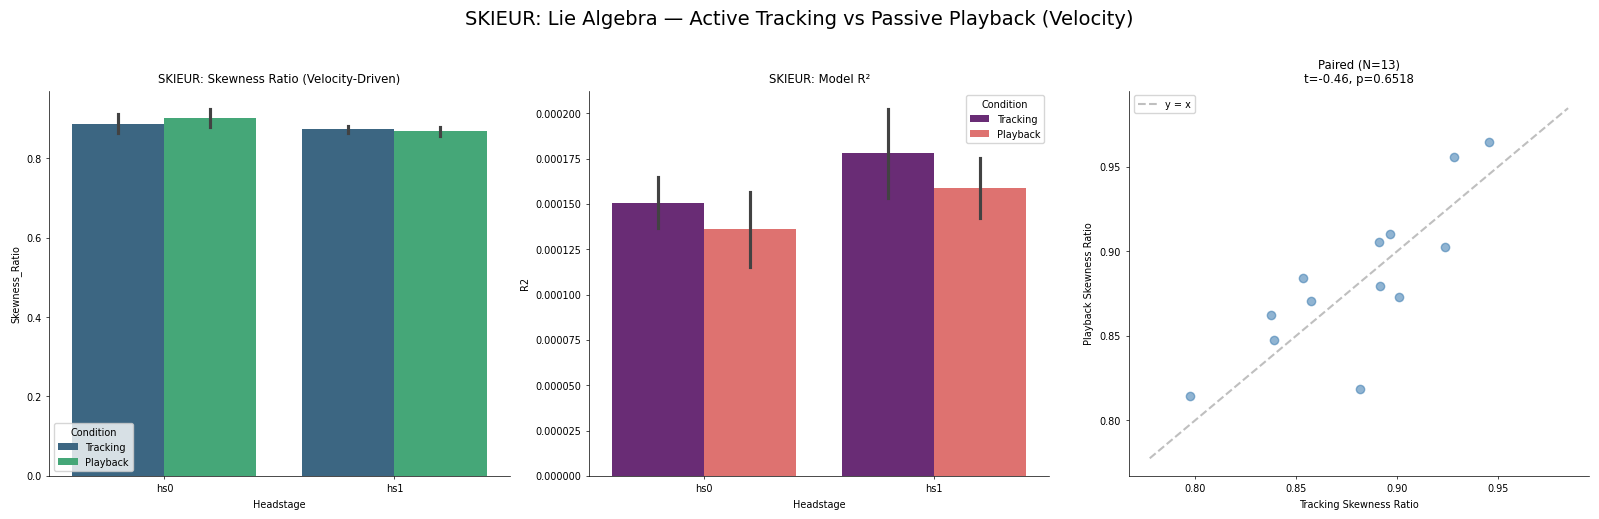

Paired t-test (N=13 pairs):
  Skewness Ratio: t=-0.463, p=0.651792
  Tracking  0.8802 +/- 0.0402
  Playback  0.8836 +/- 0.0433


In [15]:
# ============================================================
# Velocity Lie Algebra — Visualization & Paired Statistics
# ============================================================
from scipy.stats import ttest_rel

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(data=results_df, x="Headstage", y="Skewness_Ratio", hue="Condition",
            ax=axes[0], palette="viridis", errorbar="se")
axes[0].set_title("SKIEUR: Skewness Ratio (Velocity-Driven)")

sns.barplot(data=results_df, x="Headstage", y="R2", hue="Condition",
            ax=axes[1], palette="magma", errorbar="se")
axes[1].set_title("SKIEUR: Model R" + chr(0x00B2))

pivot = results_df.pivot_table(
    values=["Skewness_Ratio", "R2"],
    index=["Subject", "Session_Idx", "Headstage"], columns="Condition"
).dropna()

t_skew, p_skew = ttest_rel(pivot["Skewness_Ratio"]["Tracking"],
                           pivot["Skewness_Ratio"]["Playback"])

tr_vals = pivot["Skewness_Ratio"]["Tracking"].values
pb_vals = pivot["Skewness_Ratio"]["Playback"].values
axes[2].scatter(tr_vals, pb_vals, alpha=0.6, c="steelblue")
lims = [min(tr_vals.min(), pb_vals.min()) - 0.02,
        max(tr_vals.max(), pb_vals.max()) + 0.02]
axes[2].plot(lims, lims, "--", color="gray", alpha=0.5, label="y = x")
axes[2].set_xlabel("Tracking Skewness Ratio"); axes[2].set_ylabel("Playback Skewness Ratio")
axes[2].set_title(f"Paired (N={len(pivot)})\nt={t_skew:.2f}, p={p_skew:.4f}")
axes[2].legend()
plt.suptitle("SKIEUR: Lie Algebra — Active Tracking vs Passive Playback (Velocity)",
             fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

print(f"Paired t-test (N={len(pivot)} pairs):")
print(f"  Skewness Ratio: t={t_skew:.3f}, p={p_skew:.6f}")
print(f"  Tracking  {tr_vals.mean():.4f} +/- {tr_vals.std():.4f}")
print(f"  Playback  {pb_vals.mean():.4f} +/- {pb_vals.std():.4f}")

Eigenvalue paired t-test (N=13):
  |Real| (Dissipation): Tracking=0.0065, Playback=0.0039, t=1.473, p=0.166496
  |Imag| (Rotation):    Tracking=0.2419, Playback=0.2322, t=0.984, p=0.344772


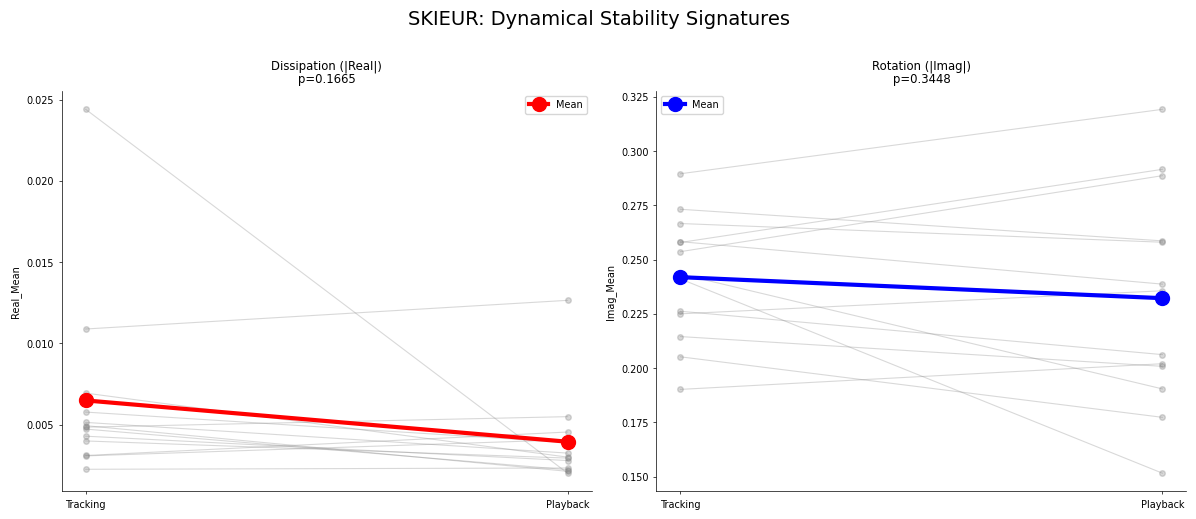

In [16]:
# ==========================================
# 4. Eigenvalue Stability Analysis
# ==========================================
min_points = 500
eig_results = []

for idx, (n_data_session, f_df) in enumerate(zip(n_data_all, f_data_all)):
    r_full = n_data_session.T
    x_dot_full = f_df["Velocity_x"].values
    conditions = f_df["Condition"].values
    hs_label = "hs0" if idx < n_hs0 else "hs1"

    for val, label in [(0.0, "Tracking"), (1.0, "Playback")]:
        epochs_n, epochs_l, n_ep = extract_epochs(
            n_data_session, f_df, val, dt,
            label_col="Velocity_x")
        if n_ep < 1:
            continue
        r_sub = np.concatenate(epochs_n, axis=0)
        x_dot_sub = np.concatenate(epochs_l, axis=0)

        try:
            _, _, _, J_raw = fit_lie_algebra_with_leak(r_sub, x_dot_sub)
            eigvals = np.linalg.eigvals(J_raw)
            real_mean = np.mean(np.abs(np.real(eigvals)))
            imag_mean = np.mean(np.abs(np.imag(eigvals)))
            eig_results.append({
                "Subject": "SKIEUR", "Session_Idx": idx, "Headstage": hs_label,
                "Condition": label, "Real_Mean": real_mean,
                "Imag_Mean": imag_mean,
                "Imag_Real_Ratio": imag_mean / real_mean if real_mean > 1e-9 else 0,
                "N_Neurons": r_full.shape[1],
            })
        except Exception as e:
            print(f"Eig error SKIEUR {idx} [{label}]: {e}")

eig_df = pd.DataFrame(eig_results)

pivot_eig = eig_df.pivot_table(
    values=["Real_Mean", "Imag_Mean"],
    index=["Subject", "Session_Idx", "Headstage"],
    columns="Condition"
).dropna()

t_real, p_real = ttest_rel(pivot_eig["Real_Mean"]["Tracking"], pivot_eig["Real_Mean"]["Playback"])
t_imag, p_imag = ttest_rel(pivot_eig["Imag_Mean"]["Tracking"], pivot_eig["Imag_Mean"]["Playback"])

print("Eigenvalue paired t-test (N=" + str(len(pivot_eig)) + "):")
print("  |Real| (Dissipation): Tracking=" + str(round(pivot_eig["Real_Mean"]["Tracking"].mean(), 4)) + ", Playback=" + str(round(pivot_eig["Real_Mean"]["Playback"].mean(), 4)) + ", t=" + str(round(t_real, 3)) + ", p=" + str(round(p_real, 6)))
print("  |Imag| (Rotation):    Tracking=" + str(round(pivot_eig["Imag_Mean"]["Tracking"].mean(), 4)) + ", Playback=" + str(round(pivot_eig["Imag_Mean"]["Playback"].mean(), 4)) + ", t=" + str(round(t_imag, 3)) + ", p=" + str(round(p_imag, 6)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
configs = [
    (axes[0], "Real_Mean", "Dissipation (|Real|)\n" + "p=" + str(round(p_real, 4)), p_real, "red"),
    (axes[1], "Imag_Mean", "Rotation (|Imag|)\n" + "p=" + str(round(p_imag, 4)), p_imag, "blue"),
]
for ax, col, ttl, p_val, color in configs:
    for _, row in pivot_eig.iterrows():
        ax.plot([0, 1], [row[col]["Tracking"], row[col]["Playback"]],
                "o-", color="gray", alpha=0.3, markersize=4, linewidth=0.8)
    ax.plot([0, 1], [pivot_eig[col]["Tracking"].mean(), pivot_eig[col]["Playback"].mean()],
            "o-", color=color, linewidth=3, markersize=10, label="Mean")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Tracking", "Playback"])
    ax.set_ylabel(col)
    ax.set_title(ttl)
    ax.legend()

plt.suptitle("SKIEUR: Dynamical Stability Signatures", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 1.2 Position-Driven

Position-driven analysis: 26 entries
                     Skewness_Ratio      R2
Headstage Condition                        
hs0       Playback           0.8988  0.0001
          Tracking           0.8756 -0.0001
hs1       Playback           0.8759  0.0001
          Tracking           0.8542  0.0000

  Velocity-driven vs Position-driven Skewness Ratio

  Driver       Condition     Skewness (mean)    R2 (mean)
  -------------------------------------------------------
  Velocity     Tracking      0.8802            0.0002
  Velocity     Playback      0.8836            0.0001
  Position     Tracking      0.8641            -0.0000
  Position     Playback      0.8865            0.0001

Position-driven paired t-test (N=13):
  t=-3.159, p=0.008237
  Tracking  Skewness: 0.8641 +/- 0.0461
  Playback  Skewness: 0.8865 +/- 0.0402


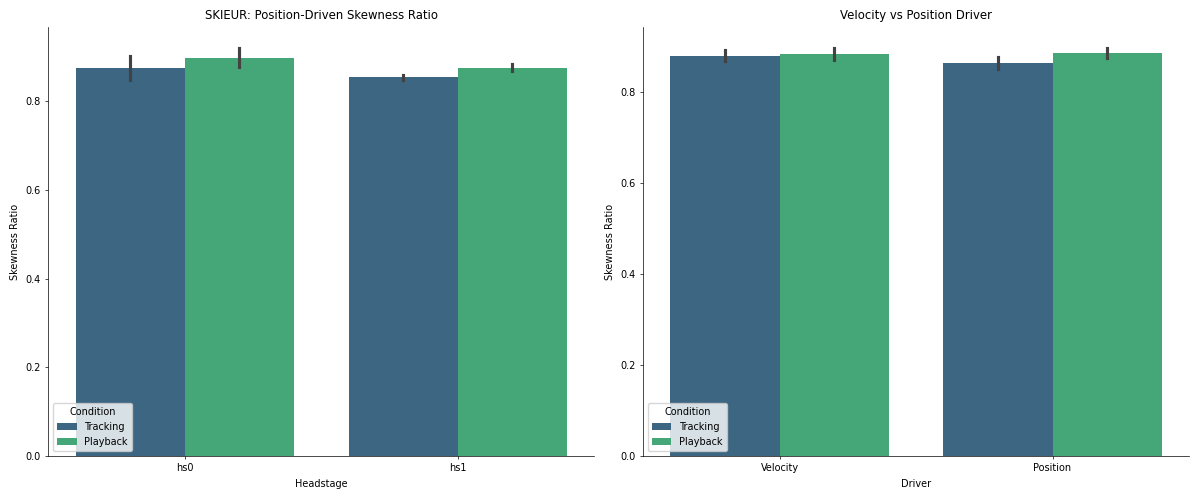

In [17]:
# ==========================================
# 4.1 Position-Driven Lie Algebra
# ==========================================

# Reuse the same fit function, but drive with Position instead of Velocity
# dR/dt = J * R * x + L * R

pos_results = []

for idx, (n_data_session, f_df) in enumerate(zip(n_data_all, f_data_all)):
    r_full = n_data_session.T
    x_full = f_df["Position"].values  # position as driver
    conditions = f_df["Condition"].values
    hs_label = "hs0" if idx < n_hs0 else "hs1"

    for val, label in [(0.0, "Tracking"), (1.0, "Playback")]:
        epochs_n, epochs_l, n_ep = extract_epochs(
            n_data_session, f_df, val, dt,
            label_col="Position")
        if n_ep < 1:
            continue
        r_sub = np.concatenate(epochs_n, axis=0)
        x_sub = np.concatenate(epochs_l, axis=0)

        try:
            J_skew, skew_ratio, r2, J_full = fit_lie_algebra_with_leak(r_sub, x_sub)
            pos_results.append({
                "Subject": "SKIEUR",
                "Session_Idx": idx,
                "Headstage": hs_label,
                "Condition": label,
                "Skewness_Ratio": skew_ratio,
                "R2": r2,
                "N_Neurons": r_sub.shape[1],
            })
        except Exception as e:
            print(f"Error SKIEUR {idx} [{label}]: {e}")

pos_df = pd.DataFrame(pos_results)
print("Position-driven analysis: " + str(len(pos_df)) + " entries")
print(pos_df.groupby(["Headstage", "Condition"])[["Skewness_Ratio", "R2"]].mean().round(4))

# ---- Comparison: Velocity vs Position ----
print()
print("=" * 65)
print("  Velocity-driven vs Position-driven Skewness Ratio")
print("=" * 65)
# Velocity results are in results_df
print()
print("  Driver       Condition     Skewness (mean)    R2 (mean)")
print("  " + "-" * 55)
for driver, df in [("Velocity", results_df), ("Position", pos_df)]:
    for cond in ["Tracking", "Playback"]:
        subset = df[df["Condition"] == cond]
        if len(subset) > 0:
            sk = subset["Skewness_Ratio"].mean()
            r2 = subset["R2"].mean()
            print("  {:<12s} {:<12s}  {:.4f}            {:.4f}".format(driver, cond, sk, r2))

# Paired t-test for position-driven
from scipy.stats import ttest_rel
pivot_pos = pos_df.pivot_table(
    values=["Skewness_Ratio", "R2"],
    index=["Subject", "Session_Idx", "Headstage"],
    columns="Condition"
).dropna()

t_pos, p_pos = ttest_rel(pivot_pos["Skewness_Ratio"]["Tracking"],
                          pivot_pos["Skewness_Ratio"]["Playback"])
print()
print("Position-driven paired t-test (N=" + str(len(pivot_pos)) + "):")
print("  t={:.3f}, p={:.6f}".format(t_pos, p_pos))
print("  Tracking  Skewness: {:.4f} +/- {:.4f}".format(pivot_pos["Skewness_Ratio"]["Tracking"].mean(), pivot_pos["Skewness_Ratio"]["Tracking"].std()))
print("  Playback  Skewness: {:.4f} +/- {:.4f}".format(pivot_pos["Skewness_Ratio"]["Playback"].mean(), pivot_pos["Skewness_Ratio"]["Playback"].std()))

# Barplot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=pos_df, x="Headstage", y="Skewness_Ratio", hue="Condition",
            ax=axes[0], palette="viridis", errorbar="se")
axes[0].set_title("SKIEUR: Position-Driven Skewness Ratio")
axes[0].set_ylabel("Skewness Ratio")

# Overlay velocity vs position tracking means
drivers = []
for driver, df in [("Velocity", results_df), ("Position", pos_df)]:
    for _, row in df.iterrows():
        drivers.append({"Driver": driver, "Condition": row["Condition"], "Skewness_Ratio": row["Skewness_Ratio"]})
driver_df = pd.DataFrame(drivers)
sns.barplot(data=driver_df, x="Driver", y="Skewness_Ratio", hue="Condition",
            ax=axes[1], palette="viridis", errorbar="se")
axes[1].set_title("Velocity vs Position Driver")
axes[1].set_ylabel("Skewness Ratio")
plt.tight_layout()
plt.show()

Position-driven paired t-test (N=13):
  Skewness: t=-3.159, p=0.008237
  Tracking  0.8641 +/- 0.0461
  Playback  0.8865 +/- 0.0402


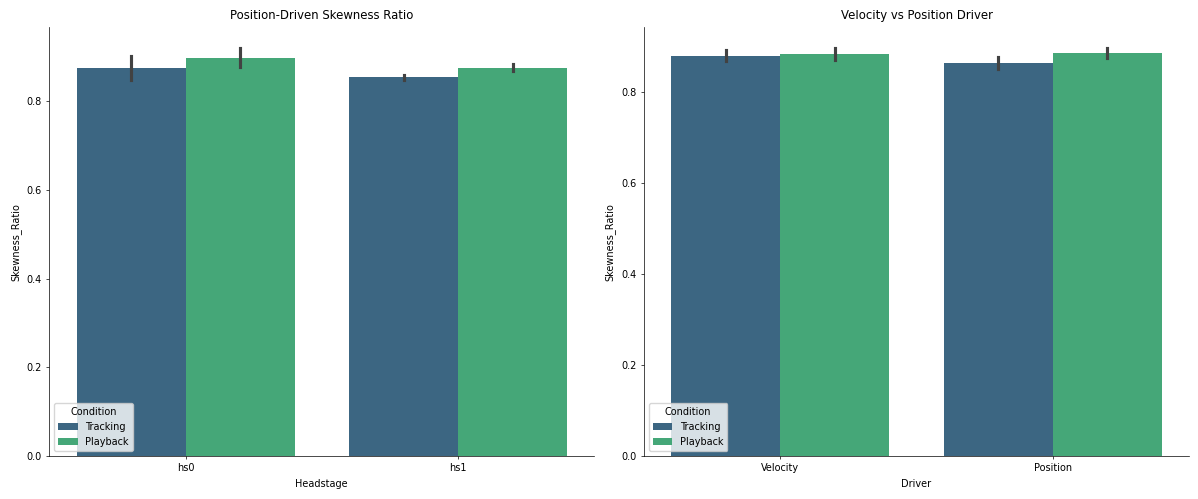

In [18]:
# ============================================================
# Position Lie Algebra — Visualization & Paired Statistics
# ============================================================
from scipy.stats import ttest_rel

pivot_pos = pos_df.pivot_table(
    values=["Skewness_Ratio", "R2"],
    index=["Subject", "Session_Idx", "Headstage"], columns="Condition"
).dropna()

t_pos, p_pos = ttest_rel(pivot_pos["Skewness_Ratio"]["Tracking"],
                          pivot_pos["Skewness_Ratio"]["Playback"])

print(f"Position-driven paired t-test (N={len(pivot_pos)}):")
print(f"  Skewness: t={t_pos:.3f}, p={p_pos:.6f}")
print(f"  Tracking  {pivot_pos['Skewness_Ratio']['Tracking'].mean():.4f} +/- {pivot_pos['Skewness_Ratio']['Tracking'].std():.4f}")
print(f"  Playback  {pivot_pos['Skewness_Ratio']['Playback'].mean():.4f} +/- {pivot_pos['Skewness_Ratio']['Playback'].std():.4f}")

# Comparison barplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=pos_df, x="Headstage", y="Skewness_Ratio", hue="Condition",
            ax=axes[0], palette="viridis", errorbar="se")
axes[0].set_title("Position-Driven Skewness Ratio")

drivers = []
for driver, df in [("Velocity", results_df), ("Position", pos_df)]:
    for _, row in df.iterrows():
        drivers.append({"Driver": driver, "Condition": row["Condition"],
                        "Skewness_Ratio": row["Skewness_Ratio"]})
driver_df = pd.DataFrame(drivers)
sns.barplot(data=driver_df, x="Driver", y="Skewness_Ratio", hue="Condition",
            ax=axes[1], palette="viridis", errorbar="se")
axes[1].set_title("Velocity vs Position Driver")
plt.tight_layout(); plt.show()

Position Eigenvalue paired t-test (N=13):
  |Real| (Dissipation): Tracking=0.0063, Playback=0.0012, t=3.292, p=0.006434
  |Imag| (Rotation):    Tracking=0.1082, Playback=0.0959, t=4.873, p=0.000383


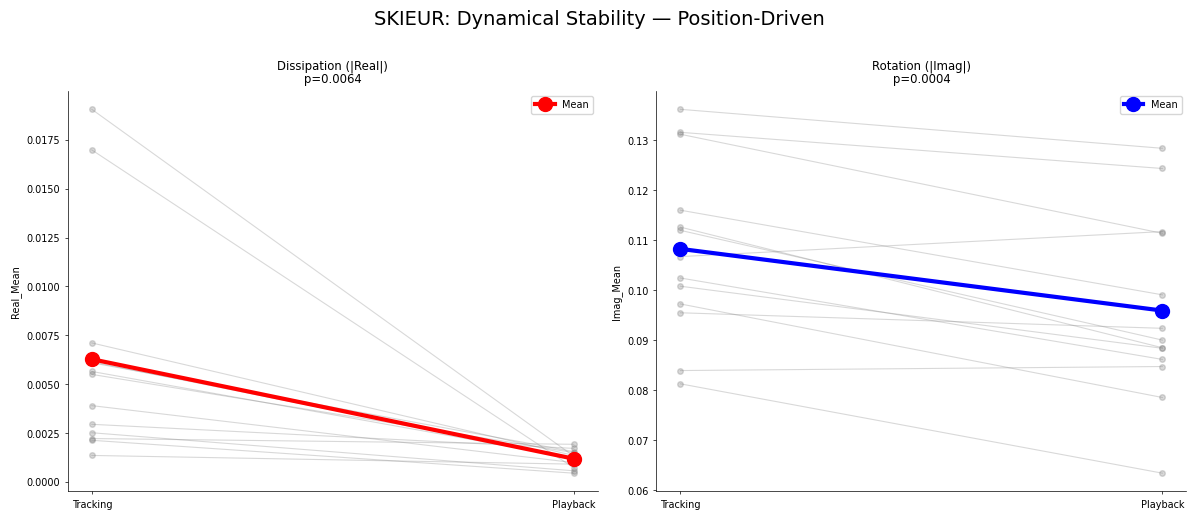

In [19]:
# ============================================================
# Position Eigenvalue Stability Analysis
# ============================================================
min_points = 500
eig_results_pos = []

for idx, (n_data_session, f_df) in enumerate(zip(n_data_all, f_data_all)):
    r_full = n_data_session.T
    x_full = f_df["Position"].values
    conditions = f_df["Condition"].values
    hs_label = "hs0" if idx < n_hs0 else "hs1"

    for val, label in [(0.0, "Tracking"), (1.0, "Playback")]:
        # Extract peri-event windows
        epochs_n, epochs_l, n_ep = extract_epochs(
            n_data_session, f_df, val, dt,
            label_col="Position")
        if n_ep < 1:
            continue
        r_sub = np.concatenate(epochs_n, axis=0)
        x_sub = np.concatenate(epochs_l, axis=0)

        try:
            _, _, _, J_raw = fit_lie_algebra_with_leak(r_sub, x_sub)
            eigvals = np.linalg.eigvals(J_raw)
            real_mean = np.mean(np.abs(np.real(eigvals)))
            imag_mean = np.mean(np.abs(np.imag(eigvals)))
            eig_results_pos.append({
                "Subject": "SKIEUR", "Session_Idx": idx, "Headstage": hs_label,
                "Condition": label,
                "Real_Mean": real_mean, "Imag_Mean": imag_mean,
                "Imag_Real_Ratio": imag_mean / real_mean if real_mean > 1e-9 else 0,
                "N_Neurons": r_full.shape[1],
            })
        except Exception as e:
            print(f"Eig error SKIEUR {idx} [{label}]: {e}")

eig_pos_df = pd.DataFrame(eig_results_pos)

pivot_eig_pos = eig_pos_df.pivot_table(
    values=["Real_Mean", "Imag_Mean"],
    index=["Subject", "Session_Idx", "Headstage"], columns="Condition"
).dropna()

t_real_p, p_real_p = ttest_rel(pivot_eig_pos["Real_Mean"]["Tracking"],
                                pivot_eig_pos["Real_Mean"]["Playback"])
t_imag_p, p_imag_p = ttest_rel(pivot_eig_pos["Imag_Mean"]["Tracking"],
                                pivot_eig_pos["Imag_Mean"]["Playback"])

print("Position Eigenvalue paired t-test (N=" + str(len(pivot_eig_pos)) + "):")
print(f"  |Real| (Dissipation): Tracking={pivot_eig_pos['Real_Mean']['Tracking'].mean():.4f}, "
      f"Playback={pivot_eig_pos['Real_Mean']['Playback'].mean():.4f}, "
      f"t={t_real_p:.3f}, p={p_real_p:.6f}")
print(f"  |Imag| (Rotation):    Tracking={pivot_eig_pos['Imag_Mean']['Tracking'].mean():.4f}, "
      f"Playback={pivot_eig_pos['Imag_Mean']['Playback'].mean():.4f}, "
      f"t={t_imag_p:.3f}, p={p_imag_p:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
configs = [
    (axes[0], "Real_Mean", "Dissipation (|Real|)\np=" + str(round(p_real_p, 4)), "red"),
    (axes[1], "Imag_Mean", "Rotation (|Imag|)\np=" + str(round(p_imag_p, 4)), "blue"),
]
for ax, col, ttl, color in configs:
    for _, row in pivot_eig_pos.iterrows():
        ax.plot([0, 1], [row[col]["Tracking"], row[col]["Playback"]],
                "o-", color="gray", alpha=0.3, markersize=4, linewidth=0.8)
    ax.plot([0, 1], [pivot_eig_pos[col]["Tracking"].mean(), pivot_eig_pos[col]["Playback"].mean()],
            "o-", color=color, linewidth=3, markersize=10, label="Mean")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Tracking", "Playback"])
    ax.set_ylabel(col); ax.set_title(ttl); ax.legend()
plt.suptitle("SKIEUR: Dynamical Stability — Position-Driven", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## 2. CEBRA Manifold Analysis

3D manifold visualization + statistical validation (InfoNCE loss, k-NN decoding R$^2$, shuffle test).

**Note:** May consume significant GPU memory. `gc.collect()` + `torch.cuda.empty_cache()` are called after each section.

### 2.1 Velocity-Driven

In [20]:
# ==========================================
# 5. 3D Manifold HTML Visualization (Plotly)
# ==========================================
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

try:
    import cebra
    from cebra import CEBRA
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    HAS_CEBRA = True
    print("CEBRA is available")
except ImportError:
    HAS_CEBRA = False
    print("CEBRA not installed. This cell requires: pip install cebra")

if HAS_CEBRA:

    def run_cebra_skieur(n_data_list, f_data_list, n_hs0, dt=0.005):
        """Train CEBRA on L2-normalized neural data, split by Tracking/Playback.
        Uses signed Velocity_x as labels.
        """
        results = {}
        for val, label in [(0.0, "Tracking"), (1.0, "Playback")]:
            neural_list = []
            label_list = []
            sid_list = []

            for s_idx, (n_raw, f_df) in enumerate(zip(n_data_list, f_data_list)):
                # Extract peri-event windows (±0.3s around Frequency_changes==1)
                epochs_n, epochs_l, n_ep = extract_epochs(
                    n_raw, f_df, val, dt,
                    label_col="Velocity_x")
                if n_ep < 1:
                    continue

                # Concatenate macro-epochs within this session.
                # Condition switches form natural boundaries between epochs.
                curr_n = np.concatenate(epochs_n, axis=0)
                curr_l = np.concatenate(epochs_l, axis=0).reshape(-1, 1)

                norms = np.linalg.norm(curr_n, axis=1, keepdims=True)
                norms[norms == 0] = 1e-9
                curr_n_norm = curr_n / norms

                neural_list.append(curr_n_norm)
                label_list.append(curr_l)
                sid_list.append(np.full(len(curr_l), s_idx))

            if not neural_list:
                continue

            hs_counts = sum(1 for i in range(len(neural_list)) if i < n_hs0)
            print(f"  {label}: {len(neural_list)} sessions (hs0={hs_counts}, hs1={len(neural_list)-hs_counts})")

            model = CEBRA(
                model_architecture="offset10-model",
                output_dimension=3,
                max_iterations=3000,
                batch_size=512,
                learning_rate=3e-4,
                temperature=1.5,
                distance=CEBRA_DISTANCE,
                conditional="time_delta",
                device="cuda",
                verbose=True
            )
            model.fit(neural_list, label_list)

            embeddings_list = []
            for i, curr_n_norm in enumerate(neural_list):
                curr_emb = model.transform(curr_n_norm, session_id=i)
                embeddings_list.append(curr_emb)

            emb_all = np.concatenate(embeddings_list, axis=0)
            results[label] = (
                emb_all,
                np.concatenate(label_list).flatten(),
                np.concatenate(sid_list)
            )
            print(f"  {label} complete.")

        return results

    def visualize_skieur_webgl(cebra_res, save_dir, downsample_factor=10):
        """Plotly WebGL 3D scatter: Tracking (left) vs Playback (right).
        Optimized: downsampling + float rounding + CDN for small HTML."""
        fig = make_subplots(
            rows=1, cols=2,
            specs=[[{"type": "scene"}, {"type": "scene"}]],
            subplot_titles=("<b>Active Tracking (SKIEUR)</b>",
                            "<b>Passive Playback (SKIEUR)</b>")
        )

        all_embs = np.concatenate([res[0] for res in cebra_res.values()])
        axis_max = np.max(np.abs(all_embs)) * 1.1

        all_labels = np.concatenate([res[1] for res in cebra_res.values()])
        cmin = float(np.percentile(all_labels, 2))
        cmax = float(np.percentile(all_labels, 98))

        fig.add_trace(
            go.Scatter3d(
                x=[0, 0], y=[0, 0], z=[0, 0],
                mode="markers",
                marker=dict(
                    size=0.001,
                    color=[cmin, cmax],
                    colorscale="Plasma",
                    cmin=cmin, cmax=cmax,
                    showscale=True,
                    colorbar=dict(title="Velocity (signed)", x=1.05, thickness=15),
                    line=dict(width=0)
                ),
                showlegend=False, hoverinfo="skip"
            ),
            row=1, col=2
        )

        for i, cond in enumerate(["Tracking", "Playback"]):
            if cond not in cebra_res:
                continue
            emb, labels, sess_ids = cebra_res[cond]

            # In-plot downsampling for HTML size reduction
            if downsample_factor > 1:
                emb = emb[::downsample_factor]
                labels = labels[::downsample_factor]
                sess_ids = sess_ids[::downsample_factor]

            # Float precision reduction
            emb = np.round(emb, 4)
            labels_rounded = np.round(labels, 2)

            unique_sessions = np.unique(sess_ids)

            for s_id in unique_sessions:
                mask = (sess_ids == s_id)
                if not np.any(mask):
                    continue

                dynamic_size = 3 + 8 * np.abs(labels[mask]) / max(abs(cmin), abs(cmax), 1e-9)
                dynamic_size = np.round(dynamic_size, 1)

                fig.add_trace(
                    go.Scatter3d(
                        x=emb[mask, 0], y=emb[mask, 1], z=emb[mask, 2],
                        mode="markers",
                        marker=dict(
                            size=dynamic_size,
                            line=dict(width=0),
                            color=labels_rounded[mask],
                            colorscale="Plasma",
                            cmin=cmin, cmax=cmax,
                            opacity=0.4,
                            showscale=False
                        ),
                        name=f"Sess {int(s_id)}",
                        legendgroup=f"Sess {int(s_id)}",
                        showlegend=bool(i == 0)
                    ),
                    row=1, col=i + 1
                )

        scene_config = dict(
            xaxis=dict(range=[-axis_max, axis_max], visible=False),
            yaxis=dict(range=[-axis_max, axis_max], visible=False),
            zaxis=dict(range=[-axis_max, axis_max], visible=False),
            aspectmode="cube"
        )

        fig.update_layout(
            height=700,
            title_text="Shared Neural Manifold Topology: SKIEUR",
            title_x=0.5,
            scene1=scene_config,
            scene2=scene_config,
            margin=dict(l=0, r=0, b=0, t=60),
        template="plotly_white",
            legend=dict(title="Sessions", x=1.1, y=0.5)
        )

        file_name = f"CEBRA_Velocity_{CEBRA_DISTANCE}_{'macro' if USE_MACRO_EPOCH else 'peri'}.html"
        save_path = os.path.join(save_dir, file_name)
        fig.write_html(save_path, include_plotlyjs='cdn')
        print(f"Saved: {save_path}")

    # ---- Sample 5 sessions chronologically, then execute CEBRA ----
    MIN_GC = 10
    N_SAMPLE = 5
    valid_idx = [i for i, nd in enumerate(n_data_all) if nd.shape[0] >= MIN_GC]

    if len(valid_idx) <= N_SAMPLE:
        chosen = valid_idx
    else:
        chosen = [valid_idx[int(round(i * (len(valid_idx) - 1) / (N_SAMPLE - 1)))] for i in range(N_SAMPLE)]
        chosen = list(dict.fromkeys(chosen))

    n_subset = [n_data_all[i] for i in chosen]
    f_subset = [f_data_all[i] for i in chosen]
    hs0_subset = sum(1 for i in chosen if i < n_hs0)

    print(f"Sampled {len(chosen)} / {len(valid_idx)} sessions (gc >= {MIN_GC}):")
    for j, i in enumerate(chosen):
        print(f"  {j+1}. session {i}: {n_data_all[i].shape[0]} neurons, {n_data_all[i].shape[1]} timepoints")

    save_directory = r"C:\\Users\\PenPen\\Desktop\\Ferret\\Results&PLots\\Web"
    if not os.path.exists(save_directory):
        save_directory = os.path.join(os.getcwd(), "output")
        os.makedirs(save_directory, exist_ok=True)
        print(f"Fallback: {save_directory}")

    print("=" * 60)
    print("SKIEUR 3D Manifold - signed Velocity_x, 5-session sample")
    print("Output: " + save_directory)
    print("=" * 60)

    cebra_results = run_cebra_skieur(n_subset, f_subset, hs0_subset)
    visualize_skieur_webgl(cebra_results, save_directory)

    print("Done! Open CEBRA_Manifold_SKIEUR_updated.html in a browser.")
else:
    print("Skipped: CEBRA not installed. Install with: pip install cebra")

CEBRA is available
Sampled 5 / 13 sessions (gc >= 10):
  1. session 0: 12 neurons, 530545 timepoints
  2. session 3: 15 neurons, 603243 timepoints
  3. session 6: 18 neurons, 610178 timepoints
  4. session 9: 13 neurons, 601543 timepoints
  5. session 12: 13 neurons, 607223 timepoints
SKIEUR 3D Manifold - signed Velocity_x, 5-session sample
Output: C:\\Users\\PenPen\\Desktop\\Ferret\\Results&PLots\\Web
  Tracking: 5 sessions (hs0=2, hs1=3)


pos: -0.3835 neg:  8.1709 total:  7.7874 temperature:  1.5000:  46%|████▌     | 1370/3000 [01:45<02:05, 13.04it/s]


KeyboardInterrupt: 

In [ ]:
# --- GPU cleanup ---
import gc, torch
gc.collect(); torch.cuda.empty_cache()
print("GPU memory cleared.")

GPU memory cleared.


In [ ]:
# ============================================================
# 5. CEBRA Manifold Statistical Validation (last session only)
#
#    Data: peri-event windows (+/-0.3s around Frequency_changes==1)
#    Test 1: InfoNCE loss curve (true vs shuffled labels)
#    Test 2: k-NN external decoding R2 (held-out 20% of TRIALS)
#    Test 3: Shuffle test (np.roll — preserves temporal smoothness)
#
#    Design:
#      - Trial-level 80/20 split prevents data leakage.
#      - CEBRA.fit(train_n, train_l) with flat-array + guard buffers:
#        offset10-model conv kernel does NOT bleed across trial
#        boundaries (each array = independent sequence).
#      - np.roll shuffle preserves velocity power spectrum /
#        autocorrelation while breaking neural-behavior alignment.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from cebra import CEBRA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

T_PRE, T_POST = 0.3, 0.3
STEP = 5  # downsampling (GPU OOM protection)
BUFFER = 12  # guard bins between trials (> offset10 receptive field)

# ---- 0. Extract peri-event windows (each = independent trial) ----
n_raw = n_data_all[-1]
f_df = f_data_all[-1]

print(f"Session {len(n_data_all)-1} (last): {n_raw.shape[0]} neurons")

# Extract macro-epochs for BOTH conditions (all epochs used for CEBRA)
epochs_all_n, epochs_all_l = [], []
for val, label in [(0.0, "Tracking"), (1.0, "Playback")]:
    en, el, n_ep = extract_epochs(
        n_raw, f_df, val, dt,
        label_col="Velocity_x")
    epochs_all_n.extend(en)
    epochs_all_l.extend(el)

total_epochs = len(epochs_all_n)
total_samples = sum(e.shape[0] for e in epochs_all_n)
print(f"Macro-epochs (min 2.0s): {total_epochs} epochs, {total_samples:,} total samples")
print(f"Velocity range: [{min(l.min() for l in epochs_all_l):.1f}, {max(l.max() for l in epochs_all_l):.1f}]")

# Downsample each epoch for GPU memory
windows_n, windows_l = [], []
for en, el in zip(epochs_all_n, epochs_all_l):
    windows_n.append(en[::STEP].astype(np.float32))
    windows_l.append(el[::STEP].astype(np.float32))
n_skipped = 0

# L2 normalize each trial independently
windows_n_norm = []
for win in windows_n:
    norms = np.linalg.norm(win, axis=1, keepdims=True)
    norms[norms == 0] = 1e-9
    windows_n_norm.append(win / norms)

win_bins = windows_n_norm[0].shape[0]
n_trials = len(windows_n_norm)
total_samples = sum(len(l) for l in windows_l)
print(f"Kept {n_trials} trials, {total_samples:,} total samples")
print(f"Window: {win_bins} bins after STEP={STEP}")
print(f"Velocity range: [{min(l.min() for l in windows_l):.1f}, {max(l.max() for l in windows_l):.1f}]")

# ---- Trial-level 80/20 split (no leakage) ----
trial_indices = np.arange(n_trials)
train_idx, test_idx = train_test_split(trial_indices, test_size=0.2, random_state=42)

train_n = [windows_n_norm[i] for i in train_idx]
train_l = [windows_l[i] for i in train_idx]
test_n  = [windows_n_norm[i] for i in test_idx]
test_l  = [windows_l[i] for i in test_idx]

train_samples = sum(len(l) for l in train_l)
test_samples  = sum(len(l) for l in test_l)
print(f"Train: {len(train_n)} trials, {train_samples:,} samples")
print(f"Test:  {len(test_n)} trials, {test_samples:,} samples")

# ---- Insert guard buffers + flatten for single-array CEBRA ----
# 12 zero-bin buffers between trials prevent offset10-model conv
# kernel from bleeding across trial boundaries. Buffer labels
# equal the last label of the preceding trial, keeping time_delta
# stats stable without creating meaningful signal.
train_n_buffered = []
train_l_buffered = []
for i, (tn, tl) in enumerate(zip(train_n, train_l)):
    train_n_buffered.append(tn)
    train_l_buffered.append(tl)
    if i < len(train_n) - 1:
        train_n_buffered.append(np.zeros((BUFFER, tn.shape[1]), dtype=np.float32))
        train_l_buffered.append(np.full(BUFFER, tl[-1], dtype=np.float32))

test_n_buffered = []
test_l_buffered = []
for i, (tn, tl) in enumerate(zip(test_n, test_l)):
    test_n_buffered.append(tn)
    test_l_buffered.append(tl)
    if i < len(test_n) - 1:
        test_n_buffered.append(np.zeros((BUFFER, tn.shape[1]), dtype=np.float32))
        test_l_buffered.append(np.full(BUFFER, tl[-1], dtype=np.float32))

X_train_flat = np.concatenate(train_n_buffered, axis=0)
y_train_flat = np.concatenate(train_l_buffered)
X_test_flat = np.concatenate(test_n_buffered, axis=0)
y_test_flat = np.concatenate(test_l_buffered)

# ---- Shuffled-label control (np.roll — preserves smoothness) ----
random_shift = np.random.randint(50, 100)
y_train_shuf_flat = np.roll(y_train_flat, random_shift)


# ============================================================
# Test 1: InfoNCE loss curves (flat-array + guard buffers)
# ============================================================
print()
print("=" * 60)
print("  [Test 1] InfoNCE Loss: True vs Shuffled Labels")
print("=" * 60)

# Single-array API with guard buffers between trials.
cebra_true = CEBRA(
    model_architecture="offset10-model", output_dimension=3,
    max_iterations=3000, batch_size=128, distance=CEBRA_DISTANCE,
    conditional="time_delta", device="cpu", verbose=True
)
print("  Training True Label model...")
cebra_true.fit(X_train_flat, y_train_flat)

cebra_shuffle = CEBRA(
    model_architecture="offset10-model", output_dimension=3,
    max_iterations=3000, batch_size=128, distance=CEBRA_DISTANCE,
    conditional="time_delta", device="cpu", verbose=True
)
print("  Training Shuffled Label model (np.roll)...")
cebra_shuffle.fit(X_train_flat, y_train_shuf_flat)

# Plot loss curves
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cebra_true.state_dict_['loss'], label='True Label Model', color='darkred')
ax.plot(cebra_shuffle.state_dict_['loss'], label='Shuffled Label Model (roll)', color='gray', linestyle='--')
ax.set_title("Validation 1: InfoNCE Loss Convergence\n(SKIEUR -- last session, {} train trials, flat + buffer)".format(len(train_n)))
ax.set_xlabel("Iterations")
ax.set_ylabel("InfoNCE Loss")
ax.legend()
plt.tight_layout()
plt.show()

final_loss_true = cebra_true.state_dict_['loss'][-1]
final_loss_shuffle = cebra_shuffle.state_dict_['loss'][-1]
print(f"  True model final loss:     {final_loss_true:.4f}")
print(f"  Shuffle model final loss:  {final_loss_shuffle:.4f}")


# ============================================================
# Test 2 & 3: k-NN external decoding + Shuffle test
# ============================================================
print()
print("=" * 60)
print("  [Test 2 & 3] k-NN Decoding R2 + Shuffle Baseline")
print("=" * 60)

# Transform each trial individually — CEBRA does NOT bleed
# receptive fields across trial boundaries.
print("  Projecting train/test into 3D manifold...")
emb_train_true = cebra_true.transform(X_train_flat)
emb_train_shuffle = cebra_shuffle.transform(X_train_flat)
emb_test_true = cebra_true.transform(X_test_flat)
emb_test_shuffle = cebra_shuffle.transform(X_test_flat)

print(f"  Train embedding: {emb_train_true.shape}")
print(f"  Test embedding:  {emb_test_true.shape}")

# k-NN regressors
decoder_true = KNeighborsRegressor(n_neighbors=5, weights='distance')
decoder_shuffle = KNeighborsRegressor(n_neighbors=5, weights='distance')

decoder_true.fit(emb_train_true, y_train_flat)
decoder_shuffle.fit(emb_train_shuffle, y_train_shuf_flat)

y_pred_true = decoder_true.predict(emb_test_true)
y_pred_shuffle = decoder_shuffle.predict(emb_test_shuffle)

r2_true = r2_score(y_test_flat, y_pred_true)
r2_shuffle = r2_score(y_test_flat, y_pred_shuffle)


# ============================================================
# Report + Visualization
# ============================================================
print()
print("=" * 60)
print("       CEBRA Manifold Statistical Validation Report")
print("    (peri-event trials, trial-level 80/20 split)")
print("=" * 60)
print(f"  Session:         last ({windows_n_norm[0].shape[1]} neurons)")
print(f"  Train trials:    {len(train_n)}")
print(f"  Test trials:     {len(test_n)}")
print(f"  Window:          +/-{T_PRE}s, {win_bins} bins after STEP={STEP}")
print(f"  Train samples:   {train_samples:,}")
print(f"  Test samples:    {test_samples:,}")
print("-" * 60)
print(f"  [Test 1] True model final loss:              {final_loss_true:.4f}")
print(f"  [Test 1] Shuffle model final loss (roll):    {final_loss_shuffle:.4f}")
print(f"  [Test 2] True-label manifold decoding R2:    {r2_true:.4f}")
print(f"  [Test 3] Shuffled-label manifold decoding R2: {r2_shuffle:.4f}")
print("-" * 60)

if r2_true > 0.3 and r2_true > (r2_shuffle + 0.2):
    print("  [CONCLUSION]: Manifold validation PASSED.")
    print("  The neural population successfully encodes velocity")
    print("  in a nonlinear manifold, ruling out overfitting.")
else:
    print("  [CONCLUSION]: Manifold validation FAILED.")
    print("  True vs shuffled models show no meaningful difference.")
    print("  The manifold may be superficial or noise-driven.")
print("=" * 60)
print("  Note: single-session, trial-level split only.")
print("  Cross-session consistency requires additional testing.")

# True vs Predicted scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(y_test_flat[::20], y_pred_true[::20], alpha=0.3, s=1, c='darkred')
lims = [min(y_test_flat.min(), y_pred_true.min()), max(y_test_flat.max(), y_pred_true.max())]
ax.plot(lims, lims, '--', color='gray', alpha=0.5)
ax.set_xlabel("True Velocity")
ax.set_ylabel("Predicted Velocity")
ax.set_title(f"True Label Model\nR2 = {r2_true:.4f}")
ax.set_xlim(lims); ax.set_ylim(lims)

ax = axes[1]
ax.scatter(y_test_flat[::20], y_pred_shuffle[::20], alpha=0.3, s=1, c='gray')
ax.plot(lims, lims, '--', color='gray', alpha=0.5)
ax.set_xlabel("True Velocity")
ax.set_ylabel("Predicted Velocity")
ax.set_title(f"Shuffled Label Model (np.roll)\nR2 = {r2_shuffle:.4f}")
ax.set_xlim(lims); ax.set_ylim(lims)

plt.suptitle("SKIEUR: CEBRA Manifold Decoding -- True vs Predicted Velocity\n(peri-event +/-0.3s, {} trials, single last session)".format(n_trials),
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print()
print(">>> CEBRA manifold statistical validation complete.")

Session 12 (last): 13 neurons
Total triggers (Frequency_changes==1): 7903
Peri-event window: +/-0.3s
Kept 7903 trials, 197,575 total samples
Window: 25 bins after STEP=5
Velocity range: [-70.5, 68.3]
Train: 6322 trials, 158,050 samples
Test:  1581 trials, 39,525 samples

  [Test 1] InfoNCE Loss: True vs Shuffled Labels
  Training True Label model...


  0%|          | 0/3000 [00:18<?, ?it/s]


RuntimeError: The following operation failed in the TorchScript interpreter.
Traceback of TorchScript (most recent call last):
  File "c:\Users\PenPen\anaconda3\envs\Latest\Lib\site-packages\cebra\models\criterions.py", line 58, in dot_similarity
    """
    pos_dist = torch.einsum("ni,ni->n", ref, pos)
    neg_dist = torch.einsum("ni,mi->nm", ref, neg)
               ~~~~~~~~~~~~ <--- HERE
    return pos_dist, neg_dist
RuntimeError: CUDA out of memory. Tried to allocate 2439.44 GiB. GPU 0 has a total capacity of 11.94 GiB of which 0 bytes is free. Of the allocated memory 15.43 GiB is allocated by PyTorch, and 946.79 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)


In [ ]:
# --- GPU cleanup ---
import gc, torch
del cebra_true, cebra_shuffle
gc.collect(); torch.cuda.empty_cache()
print("GPU memory cleared.")

NameError: name 'cebra_true' is not defined

### 2.2 Position-Driven

In [ ]:
# ============================================================
# Position-Driven CEBRA 3D Manifold
# ============================================================
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

try:
    import cebra
    from cebra import CEBRA
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    HAS_CEBRA = True
    print("CEBRA is available")
except ImportError:
    HAS_CEBRA = False
    print("CEBRA not installed")

if HAS_CEBRA:

    def run_cebra_position(n_data_list, f_data_list, n_hs0):
        """Train CEBRA on L2-normalized data with Position as label."""
        results = {}
        for val, label in [(0.0, "Tracking"), (1.0, "Playback")]:
            neural_list, label_list, sid_list = [], [], []
            for s_idx, (n_raw, f_df) in enumerate(zip(n_data_list, f_data_list)):
                epochs_n, epochs_l, n_ep = extract_epochs(
                    n_raw, f_df, val, dt, label_col="Position")
                if n_ep < 1:
                    continue
                curr_n = np.concatenate(epochs_n, axis=0)
                curr_l = np.concatenate(epochs_l, axis=0).reshape(-1, 1)
                norms = np.linalg.norm(curr_n, axis=1, keepdims=True)
                norms[norms == 0] = 1e-9
                curr_n_norm = curr_n / norms
                neural_list.append(curr_n_norm)
                label_list.append(curr_l)
                sid_list.append(np.full(len(curr_l), s_idx))
            if not neural_list:
                print(f"  {label} has no valid epochs.")
                continue
            model = CEBRA(
                model_architecture="offset10-model", output_dimension=3,
                max_iterations=3000, batch_size=2048, learning_rate=3e-4,
                temperature=1.5, distance=CEBRA_DISTANCE,
                conditional="time_delta", device="cuda", verbose=False
            )
            model.fit(neural_list, label_list)
            embeddings_list = []
            for i, curr_n_norm in enumerate(neural_list):
                curr_emb = model.transform(curr_n_norm, session_id=i)
                embeddings_list.append(curr_emb)
            emb_all = np.concatenate(embeddings_list, axis=0)
            results[label] = (
                emb_all,
                np.concatenate(label_list).flatten(),
                np.concatenate(sid_list)
            )
            print(f"  {label} complete.")
        return results


    def visualize_position_webgl(cebra_res, save_dir, downsample_factor=10):
        """Plotly WebGL 3D with Position coloring. Optimized for small HTML."""
        fig = make_subplots(
            rows=1, cols=2,
            specs=[[{"type": "scene"}, {"type": "scene"}]],
            subplot_titles=("<b>Active Tracking</b>", "<b>Passive Playback</b>")
        )
        all_embs = np.concatenate([res[0] for res in cebra_res.values()])
        axis_max = np.max(np.abs(all_embs)) * 1.1
        all_labels = np.concatenate([res[1] for res in cebra_res.values()])
        cmin = float(np.percentile(all_labels, 2))
        cmax = float(np.percentile(all_labels, 98))
        fig.add_trace(
            go.Scatter3d(x=[0, 0], y=[0, 0], z=[0, 0], mode="markers",
                marker=dict(size=0.001, color=[cmin, cmax], colorscale="Plasma",
                    cmin=cmin, cmax=cmax, showscale=True,
                    colorbar=dict(title="Position (cm)", x=1.05, thickness=15),
                    line=dict(width=0)),
                showlegend=False, hoverinfo="skip"),
            row=1, col=2
        )
        for i, cond in enumerate(["Tracking", "Playback"]):
            if cond not in cebra_res:
                continue
            emb, labels, sess_ids = cebra_res[cond]
            if downsample_factor > 1:
                emb = emb[::downsample_factor]
                labels = labels[::downsample_factor]
                sess_ids = sess_ids[::downsample_factor]
            emb = np.round(emb, 4)
            labels_rounded = np.round(labels, 2)
            unique_sessions = np.unique(sess_ids)
            for s_id in unique_sessions:
                mask = (sess_ids == s_id)
                if not np.any(mask):
                    continue
                dynamic_size = 3 + 6 * np.abs(labels[mask] - np.median(labels)) / max(abs(cmin), abs(cmax), 1e-9)
                dynamic_size = np.round(dynamic_size, 1)
                fig.add_trace(
                    go.Scatter3d(x=emb[mask, 0], y=emb[mask, 1], z=emb[mask, 2],
                        mode="markers",
                        marker=dict(size=dynamic_size, color=labels_rounded[mask],
                            colorscale="Plasma", cmin=cmin, cmax=cmax,
                            opacity=0.25, line=dict(width=0), showscale=False),
                        name=f"Sess {int(s_id)}", legendgroup=f"Sess {int(s_id)}",
                        showlegend=bool(i == 0)),
                    row=1, col=i + 1
                )
        scene_config = dict(
            xaxis=dict(range=[-axis_max, axis_max], visible=False),
            yaxis=dict(range=[-axis_max, axis_max], visible=False),
            zaxis=dict(range=[-axis_max, axis_max], visible=False),
            aspectmode="cube"
        )
        fig.update_layout(
            height=700, title_text="Neural Manifold (Position-Driven): SKIEUR",
            title_x=0.5, scene1=scene_config, scene2=scene_config,
            margin=dict(l=0, r=0, b=0, t=60),
            template="plotly_white",
            legend=dict(title="Sessions", x=1.1, y=0.5)
        )
        file_name = f"CEBRA_Position_{CEBRA_DISTANCE}_{'macro' if USE_MACRO_EPOCH else 'peri'}.html"
        save_path = os.path.join(save_dir, file_name)
        fig.write_html(save_path, include_plotlyjs='cdn')
        print(f"Saved: {save_path}")


    # ---- Sample 5 sessions chronologically, then execute CEBRA ----
    MIN_GC = 10
    N_SAMPLE = 5
    valid_idx = [i for i, nd in enumerate(n_data_all) if nd.shape[0] >= MIN_GC]
    if len(valid_idx) <= N_SAMPLE:
        chosen = valid_idx
    else:
        chosen = [valid_idx[int(round(i * (len(valid_idx) - 1) / (N_SAMPLE - 1)))] for i in range(N_SAMPLE)]
        chosen = list(dict.fromkeys(chosen))
    n_subset = [n_data_all[i] for i in chosen]
    f_subset = [f_data_all[i] for i in chosen]
    hs0_subset = sum(1 for i in chosen if i < n_hs0)
    print(f"Sampled {len(chosen)} / {len(valid_idx)} sessions")
    for j, i in enumerate(chosen):
        print(f"  {j+1}. session {i}: {n_data_all[i].shape[0]} neurons")
    save_directory = r"C:\Users\PenPen\Desktop\Ferret\Results&PLots\Web"
    if not os.path.exists(save_directory):
        os.makedirs(save_directory)
    print("=" * 60)
    print("SKIEUR 3D Manifold - Position-Driven")
    print("=" * 60)
    cebra_pos_results = run_cebra_position(n_subset, f_subset, hs0_subset)
    visualize_position_webgl(cebra_pos_results, save_directory)
    print("Done! Open CEBRA_Manifold_Position_SKIEUR.html")

else:
    print("Skipped: CEBRA not installed.")

In [ ]:
# --- GPU cleanup ---
import gc, torch
gc.collect(); torch.cuda.empty_cache()
print("GPU memory cleared.")

In [ ]:
# ============================================================
# 6. CEBRA Manifold Statistical Validation -- Position-Driven
#
#    Data: controlled by USE_MACRO_EPOCH toggle
#    Label: Position (frequency proxy)
#    Test 1: InfoNCE loss curve (true vs shuffled labels)
#    Test 2: k-NN external decoding R2 (held-out 20% of TRIALS)
#    Test 3: Shuffle test (np.roll — preserves temporal smoothness)
#
#    Design:
#      - Trial-level 80/20 split prevents data leakage.
#      - CEBRA.fit(train_n, train_l) with flat-array + guard buffers keeps
#        conv receptive field within each trial.
#      - np.roll shuffle preserves Position power spectrum while
#        breaking neural-behavior alignment.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from cebra import CEBRA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

T_PRE, T_POST = 0.3, 0.3
STEP = 5  # downsampling (GPU OOM protection)
BUFFER = 12  # guard bins between trials (> offset10 receptive field)

# ---- 0. Extract peri-event windows (each = independent trial) ----
n_raw = n_data_all[-1]
f_df = f_data_all[-1]

print(f"Session {len(n_data_all)-1} (last): {n_raw.shape[0]} neurons")

epochs_all_n, epochs_all_l = [], []
for val, label in [(0.0, "Tracking"), (1.0, "Playback")]:
    en, el, n_ep = extract_epochs(
        n_raw, f_df, val, dt, label_col="Position", step=STEP)
    epochs_all_n.extend(en)
    epochs_all_l.extend(el)

n_skipped = 0
print(f"Extraction: {'macro-epoch' if USE_MACRO_EPOCH else 'peri-event'}, {len(epochs_all_n)} segments, {sum(e.shape[0] for e in epochs_all_n):,} samples")

windows_n = epochs_all_n
windows_l = epochs_all_l

# L2 normalize each trial independently
windows_n_norm = []
for win in windows_n:
    norms = np.linalg.norm(win, axis=1, keepdims=True)
    norms[norms == 0] = 1e-9
    windows_n_norm.append(win / norms)

win_bins = windows_n_norm[0].shape[0]
n_trials = len(windows_n_norm)
total_samples = sum(len(l) for l in windows_l)
print(f"Kept {n_trials} trials, {total_samples:,} total samples")
print(f"Window: {win_bins} bins after STEP={STEP}")
print(f"Position range: [{min(l.min() for l in windows_l):.1f}, {max(l.max() for l in windows_l):.1f}]")

# ---- Trial-level 80/20 split (no leakage) ----
trial_indices = np.arange(n_trials)
train_idx, test_idx = train_test_split(trial_indices, test_size=0.2, random_state=42)

train_n = [windows_n_norm[i] for i in train_idx]
train_l = [windows_l[i] for i in train_idx]
test_n  = [windows_n_norm[i] for i in test_idx]
test_l  = [windows_l[i] for i in test_idx]

train_samples = sum(len(l) for l in train_l)
test_samples  = sum(len(l) for l in test_l)
print(f"Train: {len(train_n)} trials, {train_samples:,} samples")
print(f"Test:  {len(test_n)} trials, {test_samples:,} samples")

# ---- Shuffled-label control (np.roll — preserves smoothness) ----
random_shift = np.random.randint(50, 100)
# ---- Insert guard buffers + flatten for single-array CEBRA ----
train_n_buffered = []
train_l_buffered = []
for i, (tn, tl) in enumerate(zip(train_n, train_l)):
    train_n_buffered.append(tn)
    train_l_buffered.append(tl)
    if i < len(train_n) - 1:
        train_n_buffered.append(np.zeros((BUFFER, tn.shape[1]), dtype=np.float32))
        train_l_buffered.append(np.full(BUFFER, tl[-1], dtype=np.float32))

test_n_buffered = []
test_l_buffered = []
for i, (tn, tl) in enumerate(zip(test_n, test_l)):
    test_n_buffered.append(tn)
    test_l_buffered.append(tl)
    if i < len(test_n) - 1:
        test_n_buffered.append(np.zeros((BUFFER, tn.shape[1]), dtype=np.float32))
        test_l_buffered.append(np.full(BUFFER, tl[-1], dtype=np.float32))

X_train_flat = np.concatenate(train_n_buffered, axis=0)
y_train_flat = np.concatenate(train_l_buffered)
X_test_flat = np.concatenate(test_n_buffered, axis=0)
y_test_flat = np.concatenate(test_l_buffered)

# ---- Shuffled-label control (np.roll — preserves smoothness) ----
random_shift = np.random.randint(50, 100)
y_train_shuf_flat = np.roll(y_train_flat, random_shift)


# ============================================================
# Test 1: InfoNCE loss curves (flat-array + guard buffers)
# ============================================================
print()
print("=" * 60)
print("  [Test 1] InfoNCE Loss: True vs Shuffled Labels")
print("=" * 60)

cebra_true = CEBRA(
    model_architecture="offset10-model", output_dimension=3,
    max_iterations=3000, batch_size=256, distance=CEBRA_DISTANCE,
    conditional="time_delta", device="cuda", verbose=True
)
print("  Training True Label model (Position)...")
cebra_true.fit(X_train_flat, y_train_flat)

cebra_shuffle = CEBRA(
    model_architecture="offset10-model", output_dimension=3,
    max_iterations=3000, batch_size=256, distance=CEBRA_DISTANCE,
    conditional="time_delta", device="cuda", verbose=True
)
print("  Training Shuffled Label model (np.roll)...")
cebra_shuffle.fit(X_train_flat, y_train_shuf_flat)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cebra_true.state_dict_['loss'], label='True Label Model', color='darkred')
ax.plot(cebra_shuffle.state_dict_['loss'], label='Shuffled Label Model (roll)', color='gray', linestyle='--')
ax.set_title("Validation 1: InfoNCE Loss Convergence\n(SKIEUR -- last session, {} train trials, Position label)".format(len(train_n)))
ax.set_xlabel("Iterations")
ax.set_ylabel("InfoNCE Loss")
ax.legend()
plt.tight_layout()
plt.show()

final_loss_true = cebra_true.state_dict_['loss'][-1]
final_loss_shuffle = cebra_shuffle.state_dict_['loss'][-1]
print(f"  True model final loss:     {final_loss_true:.4f}")
print(f"  Shuffle model final loss:  {final_loss_shuffle:.4f}")


# ============================================================
# Test 2 & 3: k-NN external decoding + Shuffle test
# ============================================================
print()
print("=" * 60)
print("  [Test 2 & 3] k-NN Decoding R2 + Shuffle Baseline")
print("=" * 60)

print("  Projecting train/test trials into 3D manifold...")
emb_train_true = cebra_true.transform(X_train_flat)
emb_train_shuffle = cebra_shuffle.transform(X_train_flat)
emb_test_true = cebra_true.transform(X_test_flat)
emb_test_shuffle = cebra_shuffle.transform(X_test_flat)

print(f"  Train embedding: {emb_train_true.shape}")
print(f"  Test embedding:  {emb_test_true.shape}")

decoder_true = KNeighborsRegressor(n_neighbors=5, weights='distance')
decoder_shuffle = KNeighborsRegressor(n_neighbors=5, weights='distance')

decoder_true.fit(emb_train_true, y_train_flat)
decoder_shuffle.fit(emb_train_shuffle, y_train_shuf_flat)

y_pred_true = decoder_true.predict(emb_test_true)
y_pred_shuffle = decoder_shuffle.predict(emb_test_shuffle)

r2_true = r2_score(y_test_flat, y_pred_true)
r2_shuffle = r2_score(y_test_flat, y_pred_shuffle)


# ============================================================
# Report + Visualization
# ============================================================
print()
print("=" * 60)
print("    CEBRA Manifold Statistical Validation Report")
print("         (Position-Driven, trial-level split)")
print("=" * 60)
print(f"  Session:         last ({windows_n_norm[0].shape[1]} neurons)")
print(f"  Label:           Position (frequency proxy)")
print(f"  Train trials:    {len(train_n)}")
print(f"  Test trials:     {len(test_n)}")
print(f"  Window:          +/-{T_PRE}s, {win_bins} bins after STEP={STEP}")
print(f"  Train samples:   {train_samples:,}")
print(f"  Test samples:    {test_samples:,}")
print("-" * 60)
print(f"  [Test 1] True model final loss:              {final_loss_true:.4f}")
print(f"  [Test 1] Shuffle model final loss (roll):    {final_loss_shuffle:.4f}")
print(f"  [Test 2] True-label manifold decoding R2:    {r2_true:.4f}")
print(f"  [Test 3] Shuffled-label manifold decoding R2: {r2_shuffle:.4f}")
print("-" * 60)

if r2_true > 0.3 and r2_true > (r2_shuffle + 0.2):
    print("  [CONCLUSION]: Manifold validation PASSED.")
else:
    print("  [CONCLUSION]: Manifold validation FAILED.")
print("=" * 60)

# True vs Predicted scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(y_test_flat[::20], y_pred_true[::20], alpha=0.3, s=1, c='darkred')
lims = [min(y_test_flat.min(), y_pred_true.min()), max(y_test_flat.max(), y_pred_true.max())]
ax.plot(lims, lims, '--', color='gray', alpha=0.5)
ax.set_xlabel("True Position")
ax.set_ylabel("Predicted Position")
ax.set_title(f"True Label Model\nR2 = {r2_true:.4f}")
ax.set_xlim(lims); ax.set_ylim(lims)

ax = axes[1]
ax.scatter(y_test_flat[::20], y_pred_shuffle[::20], alpha=0.3, s=1, c='gray')
ax.plot(lims, lims, '--', color='gray', alpha=0.5)
ax.set_xlabel("True Position")
ax.set_ylabel("Predicted Position")
ax.set_title(f"Shuffled Label Model (np.roll)\nR2 = {r2_shuffle:.4f}")
ax.set_xlim(lims); ax.set_ylim(lims)

plt.suptitle("SKIEUR: CEBRA Manifold Decoding -- True vs Predicted Position\n(peri-event +/-0.3s, {} trials, single last session)".format(n_trials),
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print()
print(">>> Position-driven CEBRA manifold validation complete.")

In [ ]:
# --- GPU cleanup ---
import gc, torch
del cebra_true, cebra_shuffle
gc.collect(); torch.cuda.empty_cache()
print("GPU memory cleared.")